# Week 5 — Experiment 01: First-Conduction Data Audit

**Thesis:** *Sample-Efficient Active Level-Set Estimation, with an Application to Melt-Pool Regime Boundaries*

**Data source:** [ioandanielc/sph_dataset](https://huggingface.co/datasets/ioandanielc/sph_dataset)

This notebook is an educational, cell-by-cell audit of `final-labels_all.csv`. It deliberately stops before modeling.


## Section 1 — Research question and scope

Ioan asked us to investigate a real-data regression warm-up using four process inputs—laser power (`P`), scan velocity (`VX`), laser size (`LS`), and substrate temperature (`ST`). A provisional response variable is the first stored timestep at which a simulation's `label_final` becomes `Conduction`.

Before fitting a model, we must establish what constitutes one simulation, whether the input parameters stay constant within it, how labels transition, whether the timestep is an index or physical time, and how screenshot artifacts affect the target.

**This phase does not perform level-set estimation, active learning or Gaussian Process regression.** It does not compare kernels, optimize hyperparameters, or implement leave-one-out evaluation.


## Section 2 — Environment and reproducibility


In [1]:
from __future__ import annotations

import hashlib
import json
import platform
import re
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

HF_REPO_ID = "ioandanielc/sph_dataset"
HF_FILENAME = "final-labels_all.csv"
HF_REVISION = "0e859b748fdbc8454f66e58e101e333ac0479d42"

def find_repository_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists() and (candidate / "requirements.txt").exists():
            return candidate
    raise RuntimeError("Could not locate the repository root from the current working directory.")

REPOSITORY_ROOT = find_repository_root()
NOTEBOOK_PATH = REPOSITORY_ROOT / "notebooks" / "week_05" / "01_first_conduction_data_audit.ipynb"
DATA_DIRECTORY = REPOSITORY_ROOT / "data" / "raw" / "sph_dataset"
DATA_PATH = DATA_DIRECTORY / HF_FILENAME
OUTPUT_DIRECTORY = REPOSITORY_ROOT / "outputs" / "week5_01_first_conduction_data_audit"
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 30)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.precision", 6)
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 160,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

environment_summary = pd.DataFrame(
    {
        "item": [
            "Python", "pandas", "NumPy", "repository root", "notebook path",
            "data path", "output path", "Hugging Face revision", "audit date",
        ],
        "value": [
            platform.python_version(), pd.__version__, np.__version__, str(REPOSITORY_ROOT),
            str(NOTEBOOK_PATH), str(DATA_PATH), str(OUTPUT_DIRECTORY), HF_REVISION,
            date.today().isoformat(),
        ],
    }
)
display(environment_summary)


,item,value
0,Python,3.12.13
1,pandas,2.3.3
2,NumPy,2.5.1
3,repository root,C:\Users\ozgur\Documents\thesis-week5-first-conduction-gp
4,notebook path,C:\Users\ozgur\Documents\thesis-week5-first-conduction-gp\notebooks\week_05\01_first_conduction_...
5,data path,C:\Users\ozgur\Documents\thesis-week5-first-conduction-gp\data\raw\sph_dataset\final-labels_all.csv
6,output path,C:\Users\ozgur\Documents\thesis-week5-first-conduction-gp\outputs\week5_01_first_conduction_data...
7,Hugging Face revision,0e859b748fdbc8454f66e58e101e333ac0479d42
8,audit date,2026-07-21


**Interpretation.** Paths are derived from the repository marker rather than from a fragile fixed number of parent directories, so the notebook works when launched from its own nested folder or from the repository root. Plotting and display settings are deterministic; no random or artificial data is created. This matters because future GP work must be traceable to the same raw file and revision.


In [2]:
DATA_DIRECTORY.mkdir(parents=True, exist_ok=True)
if DATA_PATH.exists():
    data_access_mode = "reused existing local cache"
else:
    from huggingface_hub import hf_hub_download

    downloaded_path = Path(
        hf_hub_download(
            repo_id=HF_REPO_ID,
            repo_type="dataset",
            filename=HF_FILENAME,
            revision=HF_REVISION,
            local_dir=DATA_DIRECTORY,
        )
    )
    if downloaded_path.resolve() != DATA_PATH.resolve():
        raise RuntimeError(f"Unexpected download path: {downloaded_path}")
    data_access_mode = "downloaded the single requested CSV"

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

CSV_SHA256 = sha256_file(DATA_PATH)
source_metadata = pd.DataFrame(
    {
        "field": ["repository", "filename", "revision", "access mode", "size (bytes)", "SHA-256"],
        "value": [HF_REPO_ID, HF_FILENAME, HF_REVISION, data_access_mode, DATA_PATH.stat().st_size, CSV_SHA256],
    }
)
display(source_metadata)


,field,value
0,repository,ioandanielc/sph_dataset
1,filename,final-labels_all.csv
2,revision,0e859b748fdbc8454f66e58e101e333ac0479d42
3,access mode,reused existing local cache
4,size (bytes),17421654
5,SHA-256,964a12d86435e9f0879e2e43384d997e1cc2faa7b9e4c3aeb49cf0e73e3fb154


**Interpretation.** The audit is pinned to one Hugging Face commit and reads only `final-labels_all.csv`. The local file is 17,421,654 bytes with SHA-256 `964a12d86435e9f0879e2e43384d997e1cc2faa7b9e4c3aeb49cf0e73e3fb154`. Reruns reuse this ignored cache instead of downloading again. This provenance is the foundation for reproducing any later target construction.


## Section 3 — Load and preview the raw CSV


In [3]:
raw = pd.read_csv(DATA_PATH)
raw_schema_summary = pd.DataFrame(
    {
        "column": raw.columns,
        "dtype": [str(raw[column].dtype) for column in raw.columns],
        "non_null_rows": [int(raw[column].notna().sum()) for column in raw.columns],
        "missing_rows": [int(raw[column].isna().sum()) for column in raw.columns],
        "unique_values": [int(raw[column].nunique(dropna=False)) for column in raw.columns],
        "example_value": [raw[column].iloc[0] for column in raw.columns],
    }
)
print(f"Shape: {raw.shape[0]:,} rows × {raw.shape[1]} columns")
print(f"Deep memory usage: {raw.memory_usage(deep=True).sum() / 1024**2:.2f} MiB")
display(raw_schema_summary)
print("First five rows")
display(raw.head())
print("Last five rows")
display(raw.tail())


Shape: 65,472 rows × 12 columns
Deep memory usage: 30.82 MiB


,column,dtype,non_null_rows,missing_rows,unique_values,example_value
0,name,object,65472,0,241,P-101p127472137_VX-0p52394730996_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_TE-0p00...
1,hash,object,65472,0,103,b0e5aed98c
2,P,float64,65472,0,241,101.127472
3,VX,float64,65472,0,230,0.523947
4,LS,float64,65472,0,215,0.000045
5,ST,float64,65472,0,215,300.0
6,bug_free,int64,65472,0,1,1
7,correctly_finished,int64,65472,0,1,1
8,timestep,int64,65472,0,49737,0
9,label_1,object,65472,0,5,Initial Emptiness


First five rows


,name,hash,P,VX,LS,ST,bug_free,correctly_finished,timestep,label_1,label_2,label_final
0,P-101p127472137_VX-0p52394730996_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_TE-0p00...,b0e5aed98c,101.127472,0.523947,0.000045,300.0,1,1,0,Initial Emptiness,Initial Emptiness,Initial Emptiness
1,P-101p127472137_VX-0p52394730996_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_TE-0p00...,b0e5aed98c,101.127472,0.523947,0.000045,300.0,1,1,197,Forming Phase,Forming Phase,Forming Phase
2,P-101p127472137_VX-0p52394730996_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_TE-0p00...,b0e5aed98c,101.127472,0.523947,0.000045,300.0,1,1,393,Forming Phase,Forming Phase,Forming Phase
3,P-101p127472137_VX-0p52394730996_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_TE-0p00...,b0e5aed98c,101.127472,0.523947,0.000045,300.0,1,1,589,Forming Phase,Forming Phase,Forming Phase
4,P-101p127472137_VX-0p52394730996_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_TE-0p00...,b0e5aed98c,101.127472,0.523947,0.000045,300.0,1,1,786,Forming Phase,Forming Phase,Forming Phase


Last five rows


,name,hash,P,VX,LS,ST,bug_free,correctly_finished,timestep,label_1,label_2,label_final
65467,P-97p9405338961_VX-0p913267755474_LS-7p48831340213e-05_ST-390p809181728_M-TI64_XI-0p0002_XF-0p00...,0b12abf205,97.940534,0.913268,0.000075,390.809182,1,1,114564,Initial Emptiness,Initial Emptiness,Initial Emptiness
65468,P-97p9405338961_VX-0p913267755474_LS-7p48831340213e-05_ST-390p809181728_M-TI64_XI-0p0002_XF-0p00...,0b12abf205,97.940534,0.913268,0.000075,390.809182,1,1,114855,Initial Emptiness,Initial Emptiness,Initial Emptiness
65469,P-97p9405338961_VX-0p913267755474_LS-7p48831340213e-05_ST-390p809181728_M-TI64_XI-0p0002_XF-0p00...,0b12abf205,97.940534,0.913268,0.000075,390.809182,1,1,115146,Initial Emptiness,Initial Emptiness,Initial Emptiness
65470,P-97p9405338961_VX-0p913267755474_LS-7p48831340213e-05_ST-390p809181728_M-TI64_XI-0p0002_XF-0p00...,0b12abf205,97.940534,0.913268,0.000075,390.809182,1,1,115437,Initial Emptiness,Initial Emptiness,Initial Emptiness
65471,P-97p9405338961_VX-0p913267755474_LS-7p48831340213e-05_ST-390p809181728_M-TI64_XI-0p0002_XF-0p00...,0b12abf205,97.940534,0.913268,0.000075,390.809182,1,1,115599,Initial Emptiness,Initial Emptiness,Initial Emptiness


**Interpretation.** The raw table contains 65,472 frame rows and 12 columns. All expected fields (`P`, `VX`, `LS`, `ST`, `timestep`, and `label_final`) are present. The additional columns are `name`, `hash`, `bug_free`, `correctly_finished`, `label_1`, and `label_2`. There are no missing values. This matters because grouping and label provenance can be audited directly rather than inferred from filenames alone.


In [4]:
expected_columns = ["P", "VX", "LS", "ST", "timestep", "label_final"]
identifier_candidates = [
    column for column in ["name", "hash", "simulation_id", "experiment_id", "run_id"]
    if column in raw.columns
]
schema_comparison = pd.DataFrame(
    {
        "expected_field": expected_columns,
        "present": [column in raw.columns for column in expected_columns],
        "actual_dtype": [str(raw[column].dtype) if column in raw.columns else "missing" for column in expected_columns],
    }
)
display(schema_comparison)
print("Plausible simulation identifiers found:", identifier_candidates)
print("Missing values by column:")
display(raw.isna().sum().rename("missing_rows").to_frame())


,expected_field,present,actual_dtype
0,P,True,float64
1,VX,True,float64
2,LS,True,float64
3,ST,True,float64
4,timestep,True,int64
5,label_final,True,object


Plausible simulation identifiers found: ['name', 'hash']
Missing values by column:


,missing_rows
name,0
hash,0
P,0
VX,0
LS,0
ST,0
bug_free,0
correctly_finished,0
timestep,0
label_1,0


**Interpretation.** The anticipated numeric fields were parsed as numeric values and the two plausible identifiers are `name` and `hash`. We have not selected one yet. Keeping that choice open until consistency tests prevents accidental merging of distinct simulations, which would corrupt a future regression target.


## Section 4 — Row-level integrity audit


In [5]:
numeric_columns = raw.select_dtypes(include=[np.number]).columns.tolist()
object_columns = raw.select_dtypes(include=["object", "string"]).columns.tolist()

duplicate_key_rows = []
for key_columns in [
    ["name", "timestep"],
    ["hash", "timestep"],
    ["P", "VX", "LS", "ST", "timestep"],
]:
    duplicate_key_rows.append(
        {
            "candidate_key": " + ".join(key_columns),
            "duplicate_rows_after_first": int(raw.duplicated(key_columns).sum()),
        }
    )
duplicate_key_audit = pd.DataFrame(duplicate_key_rows)

infinite_counts = {
    column: int(np.isinf(raw[column].to_numpy(dtype=float)).sum())
    for column in numeric_columns
}
object_audit_rows = []
for column in object_columns:
    non_null = raw[column].dropna().astype(str)
    normalized = pd.DataFrame(
        {"raw": non_null, "normalized": non_null.str.strip().str.casefold()}
    ).drop_duplicates()
    casefold_collision_count = int(
        normalized.groupby("normalized")["raw"].nunique().gt(1).sum()
    )
    object_audit_rows.append(
        {
            "column": column,
            "distinct_raw_values": int(non_null.nunique()),
            "values_with_outer_whitespace": int((non_null != non_null.str.strip()).sum()),
            "case_or_whitespace_collisions": casefold_collision_count,
        }
    )
object_value_audit = pd.DataFrame(object_audit_rows)

integrity_summary = pd.DataFrame(
    {
        "check": [
            "exact duplicate rows", "missing cells", "infinite numeric cells",
            "all expected numeric columns parsed numerically",
        ],
        "result": [
            int(raw.duplicated().sum()), int(raw.isna().sum().sum()), sum(infinite_counts.values()),
            all(pd.api.types.is_numeric_dtype(raw[column]) for column in ["P", "VX", "LS", "ST", "timestep"]),
        ],
    }
)
display(integrity_summary)
display(duplicate_key_audit)
display(object_value_audit)


,check,result
0,exact duplicate rows,0
1,missing cells,0
2,infinite numeric cells,0
3,all expected numeric columns parsed numerically,True


,candidate_key,duplicate_rows_after_first
0,name + timestep,0
1,hash + timestep,772
2,P + VX + LS + ST + timestep,0


,column,distinct_raw_values,values_with_outer_whitespace,case_or_whitespace_collisions
0,name,241,0,0
1,hash,103,0,0
2,label_1,5,0,0
3,label_2,5,0,0
4,label_final,5,0,0


**Interpretation.** There are no exact duplicate rows, missing cells, infinite numeric values, or duplicate `(name, timestep)` rows. String values have no outer-whitespace or capitalization collisions, so no silent normalization is applied. In contrast, `(hash, timestep)` is not a safe key because hashes repeat across simulations. These checks matter because duplicate or silently cleaned frames could move the apparent first-Conduction event.


In [6]:
LABEL_COLUMNS = [column for column in raw.columns if "label" in column.lower()]
label_distinct_values = pd.DataFrame(
    {
        "label_column": LABEL_COLUMNS,
        "distinct_values": [sorted(raw[column].dropna().astype(str).unique().tolist()) for column in LABEL_COLUMNS],
        "unique_count": [int(raw[column].nunique(dropna=False)) for column in LABEL_COLUMNS],
    }
)
label_agreement = pd.DataFrame(
    [
        {
            "comparison": f"{left} == {right}",
            "matching_rows": int(raw[left].eq(raw[right]).sum()),
            "mismatching_rows": int(raw[left].ne(raw[right]).sum()),
        }
        for index, left in enumerate(LABEL_COLUMNS)
        for right in LABEL_COLUMNS[index + 1 :]
    ]
)
display(label_distinct_values)
display(label_agreement)


,label_column,distinct_values,unique_count
0,label_1,"[Conduction, Forming Phase, Initial Emptiness, Keyhole, Screenshot Bug]",5
1,label_2,"[Conduction, Forming Phase, Initial Emptiness, Keyhole, Screenshot Bug]",5
2,label_final,"[Conduction, Forming Phase, Initial Emptiness, Keyhole, Screenshot Bug]",5


,comparison,matching_rows,mismatching_rows
0,label_1 == label_2,65472,0
1,label_1 == label_final,65472,0
2,label_2 == label_final,65472,0


**Interpretation.** `label_1`, `label_2`, and `label_final` agree on all 65,472 rows and each contains the same five labels. This is useful provenance, but it also means this CSV provides no observed reviewer disagreement signal for estimating label uncertainty.


## Section 5 — Label audit


In [7]:
label_count_rows = []
for label_column in LABEL_COLUMNS:
    frame_counts = raw[label_column].value_counts(dropna=False)
    for label_value, frame_count in frame_counts.items():
        label_count_rows.append(
            {
                "label_column": label_column,
                "label": label_value,
                "frame_count": int(frame_count),
                "frame_percent": float(100 * frame_count / len(raw)),
                "name_group_count": int(raw.loc[raw[label_column].eq(label_value), "name"].nunique()),
                "rare_below_1_percent": bool(frame_count / len(raw) < 0.01),
            }
        )
label_counts = pd.DataFrame(label_count_rows)
final_label_counts = label_counts.loc[label_counts["label_column"].eq("label_final")].sort_values(
    "frame_count", ascending=False
)
display(final_label_counts)


,label_column,label,frame_count,frame_percent,name_group_count,rare_below_1_percent
10,label_final,Conduction,43881,67.022544,238,False
11,label_final,Forming Phase,10326,15.771628,177,False
12,label_final,Screenshot Bug,7469,11.407930,150,False
13,label_final,Initial Emptiness,3275,5.002138,116,False
14,label_final,Keyhole,521,0.795760,9,True


**Interpretation.** At frame level, `Conduction` dominates with 43,881 rows (about 67.0%). `Screenshot Bug` appears in 7,469 frames across 150 candidate `name` groups, while `Keyhole` is rare: 521 frames across 9 groups. Frame imbalance is not experiment imbalance—a long simulation contributes more frames—so future regression diagnostics must operate at simulation level.


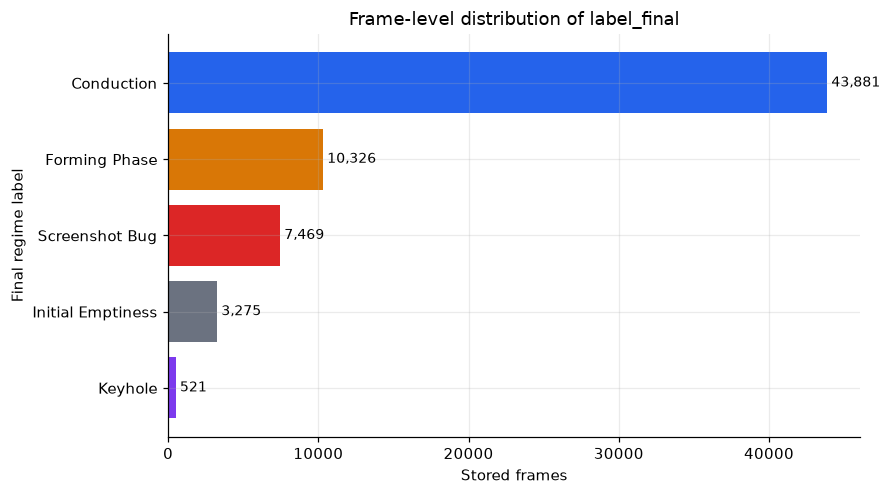

In [8]:
colors = {
    "Initial Emptiness": "#6B7280",
    "Forming Phase": "#D97706",
    "Conduction": "#2563EB",
    "Keyhole": "#7C3AED",
    "Screenshot Bug": "#DC2626",
}
plot_counts = raw["label_final"].value_counts().sort_values(ascending=True)
fig, axis = plt.subplots(figsize=(8.2, 4.6))
axis.barh(plot_counts.index, plot_counts.values, color=[colors.get(label, "#64748B") for label in plot_counts.index])
axis.set_title("Frame-level distribution of label_final")
axis.set_xlabel("Stored frames")
axis.set_ylabel("Final regime label")
for y_position, value in enumerate(plot_counts.values):
    axis.text(value, y_position, f" {value:,}", va="center", fontsize=9)
fig.tight_layout()
fig.savefig(OUTPUT_DIRECTORY / "label_final_counts.png", bbox_inches="tight")
plt.show()


**Interpretation.** The chart makes the heavy frame-level dominance of Conduction visible while preserving the small Keyhole category. This matters for later work because a model trained per simulation must not inherit frame-count weighting accidentally.


## Section 6 — Determine the correct simulation grouping key


In [9]:
PARAMETERS = ["P", "VX", "LS", "ST"]

def audit_grouping_key(data: pd.DataFrame, key: str) -> dict:
    grouped = data.groupby(key, dropna=False, sort=False)
    group_sizes = grouped.size()
    parameter_variation = grouped[PARAMETERS].nunique(dropna=False).gt(1).any(axis=1)
    names_per_group = grouped["name"].nunique(dropna=False)
    return {
        "candidate_key": key,
        "unique_groups": int(grouped.ngroups),
        "missing_identifier_rows": int(data[key].isna().sum()),
        "rows_per_group_min": int(group_sizes.min()),
        "rows_per_group_median": float(group_sizes.median()),
        "rows_per_group_max": int(group_sizes.max()),
        "groups_with_varying_P_VX_LS_ST": int(parameter_variation.sum()),
        "groups_merging_multiple_names": int(names_per_group.gt(1).sum()),
        "maximum_names_merged_in_one_group": int(names_per_group.max()),
    }

grouping_audit = pd.DataFrame([audit_grouping_key(raw, key) for key in identifier_candidates])
display(grouping_audit)

hash_collisions = (
    raw.groupby("hash")["name"]
    .nunique()
    .sort_values(ascending=False)
    .rename("distinct_names")
    .to_frame()
)
print("Largest hash-to-name collisions")
display(hash_collisions.head(10))


,candidate_key,unique_groups,missing_identifier_rows,rows_per_group_min,rows_per_group_median,rows_per_group_max,groups_with_varying_P_VX_LS_ST,groups_merging_multiple_names,maximum_names_merged_in_one_group
0,name,241,0,41,265.0,659,0,0,1
1,hash,103,0,102,405.0,6293,50,50,20


Largest hash-to-name collisions


,distinct_names
hash,
b41981edcb,20
306f9d252b,16
bf889bf790,14
b40dbd8ddd,10
fb250c7cf9,6
f404b6f8f4,6
0b12abf205,5
765072ed36,5
b0e5aed98c,5


**Interpretation.** `name` is provisionally justified: it yields 241 groups, has no missing values, keeps all four process parameters constant within every group, and never merges distinct names. `hash` yields only 103 groups; 50 hash groups merge different names, vary in process parameters, and one hash combines as many as 20 names. Therefore `hash` would conflate separate experiments and is rejected as the grouping key. This grouping decision is central to constructing one future regression row per simulation.


In [10]:
GROUP_KEY = "name"
parameter_constancy = raw.groupby(GROUP_KEY)[PARAMETERS].nunique(dropna=False)
selected_grouping_checks = pd.DataFrame(
    {
        "check": ["simulation groups", "groups with varying inputs", "missing group identifiers"],
        "value": [
            int(raw[GROUP_KEY].nunique()),
            int(parameter_constancy.gt(1).any(axis=1).sum()),
            int(raw[GROUP_KEY].isna().sum()),
        ],
    }
)
display(selected_grouping_checks)


,check,value
0,simulation groups,241
1,groups with varying inputs,0
2,missing group identifiers,0


**Interpretation.** The selected provisional key passes all internal consistency checks. “Provisional” remains important: confirmation from dataset documentation or Ioan would still strengthen the scientific interpretation before modeling.


## Section 7 — Process-parameter audit


In [11]:
simulation_parameters = raw.groupby(GROUP_KEY, sort=False)[PARAMETERS].first()
parameter_statistics = simulation_parameters.describe().T
parameter_statistics["unique_values"] = simulation_parameters.nunique()
display(parameter_statistics)

duplicated_parameter_combinations = int(simulation_parameters.duplicated(PARAMETERS, keep=False).sum())
print("Simulation rows belonging to duplicated exact 4D combinations:", duplicated_parameter_combinations)


,count,mean,std,min,25%,50%,75%,max,unique_values
P,241.0,158.179141,53.077130,52.544586,113.286682,153.721476,206.272220,248.695097,241
VX,241.0,0.617043,0.240809,0.201002,0.409013,0.621036,0.844141,0.998321,230
LS,241.0,0.000065,0.000013,0.000045,0.000054,0.000065,0.000076,0.000090,215
ST,241.0,348.481589,32.497496,300.000000,319.105471,349.969995,378.601004,399.457924,215


Simulation rows belonging to duplicated exact 4D combinations: 0


**Interpretation.** All 241 simulations have unique exact 4D parameter combinations. `P` is unique for every simulation, while some individual `VX`, `LS`, and `ST` values repeat. This provides broad scattered coverage rather than a full factorial grid; later evaluation splits must respect that geometry.


In [12]:
documented_ranges = {
    "P": (76.70, 249.99),
    "VX": (0.204, 0.998),
    "LS": (45.10e-6, 89.70e-6),
    "ST": (300.3, 399.6),
}
range_rows = []
for parameter in PARAMETERS:
    lower, upper = documented_ranges[parameter]
    observed = simulation_parameters[parameter]
    range_rows.append(
        {
            "parameter": parameter,
            "observed_min": float(observed.min()),
            "observed_max": float(observed.max()),
            "dataset_card_min": lower,
            "dataset_card_max": upper,
            "simulations_outside_card_range": int(((observed < lower) | (observed > upper)).sum()),
            "nonpositive_values": int(observed.le(0).sum()),
        }
    )
process_range_audit = pd.DataFrame(range_rows)
display(process_range_audit)
print("Exploratory Pearson correlations (not causal):")
display(simulation_parameters.corr())


,parameter,observed_min,observed_max,dataset_card_min,dataset_card_max,simulations_outside_card_range,nonpositive_values
0,P,52.544586,248.695097,76.700000,249.99000,12,0
1,VX,0.201002,0.998321,0.204000,0.99800,4,0
2,LS,0.000045,0.000090,0.000045,0.00009,28,0
3,ST,300.000000,399.457924,300.300000,399.60000,28,0


Exploratory Pearson correlations (not causal):


,P,VX,LS,ST
P,1.000000,0.072214,0.212216,0.139465
VX,0.072214,1.000000,0.035895,-0.010707
LS,0.212216,0.035895,1.000000,0.247107
ST,0.139465,-0.010707,0.247107,1.000000


**Interpretation.** No process input is nonpositive, but the CSV includes some values just outside the current dataset-card lower bounds—most notably laser power below 76.70 W, plus small lower-edge differences for velocity and substrate temperature. These may be legacy/reference simulations rather than errors and must be clarified rather than removed. Correlations are descriptive only and do not establish causal relationships.


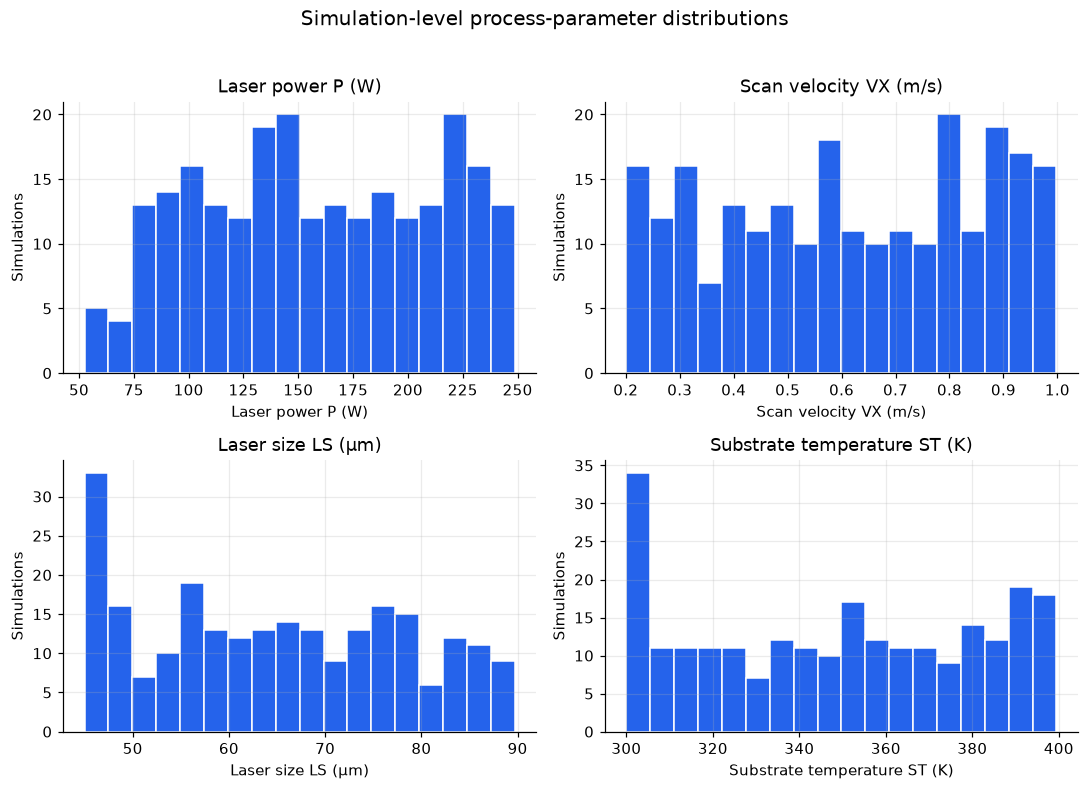

In [13]:
figure_data = simulation_parameters.copy()
figure_data["LS_um"] = figure_data["LS"] * 1e6
plot_specs = [
    ("P", "Laser power P (W)"),
    ("VX", "Scan velocity VX (m/s)"),
    ("LS_um", "Laser size LS (µm)"),
    ("ST", "Substrate temperature ST (K)"),
]
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for axis, (column, label) in zip(axes.ravel(), plot_specs):
    axis.hist(figure_data[column], bins=18, color="#2563EB", edgecolor="white")
    axis.set_title(label)
    axis.set_xlabel(label)
    axis.set_ylabel("Simulations")
fig.suptitle("Simulation-level process-parameter distributions", y=1.02, fontsize=13)
fig.tight_layout()
fig.savefig(OUTPUT_DIRECTORY / "process_parameter_distributions.png", bbox_inches="tight")
plt.show()


**Interpretation.** The four histograms show broad input-space coverage without obvious impossible spikes. Laser size is displayed in micrometres for readability, but the stored `LS` values remain unchanged in metres. Clear units are essential before any kernel length scale can be interpreted.


## Section 8 — Timestep audit


In [14]:
timestep_rows = []
for simulation_name, group in raw.groupby(GROUP_KEY, sort=False):
    timesteps = group["timestep"].to_numpy()
    gaps = np.diff(timesteps)
    timestep_rows.append(
        {
            GROUP_KEY: simulation_name,
            "minimum_timestep": int(timesteps.min()),
            "maximum_timestep": int(timesteps.max()),
            "observed_frames": int(len(timesteps)),
            "timesteps_sorted_in_raw_order": bool(np.all(gaps >= 0)),
            "duplicate_timestep_rows": int(pd.Series(timesteps).duplicated().sum()),
            "distinct_integer_gaps": int(np.unique(gaps).size) if gaps.size else 0,
            "minimum_gap": int(gaps.min()) if gaps.size else np.nan,
            "maximum_gap": int(gaps.max()) if gaps.size else np.nan,
            "exactly_constant_integer_gap": bool(np.unique(gaps).size <= 1),
        }
    )
timestep_audit = pd.DataFrame(timestep_rows)
timestep_summary = pd.DataFrame(
    {
        "metric": [
            "simulations", "unsorted schedules", "schedules with duplicate timesteps",
            "schedules with exactly constant integer gaps", "unique complete schedules",
            "simulations starting at timestep 0", "simulations starting after timestep 0",
        ],
        "value": [
            len(timestep_audit),
            int((~timestep_audit["timesteps_sorted_in_raw_order"]).sum()),
            int(timestep_audit["duplicate_timestep_rows"].gt(0).sum()),
            int(timestep_audit["exactly_constant_integer_gap"].sum()),
            int(raw.groupby(GROUP_KEY)["timestep"].apply(tuple).nunique()),
            int(timestep_audit["minimum_timestep"].eq(0).sum()),
            int(timestep_audit["minimum_timestep"].gt(0).sum()),
        ],
    }
)
display(timestep_summary)
display(timestep_audit[["minimum_timestep", "maximum_timestep", "observed_frames", "distinct_integer_gaps", "minimum_gap", "maximum_gap"]].describe())
print("Nonzero starting-timestep examples")
display(timestep_audit.loc[timestep_audit["minimum_timestep"].gt(0)].head())


,metric,value
0,simulations,241
1,unsorted schedules,0
2,schedules with duplicate timesteps,0
3,schedules with exactly constant integer gaps,0
4,unique complete schedules,241
5,simulations starting at timestep 0,239
6,simulations starting after timestep 0,2


,minimum_timestep,maximum_timestep,observed_frames,distinct_integer_gaps,minimum_gap,maximum_gap
count,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000
mean,2.887967,107402.136929,271.668050,4.966805,235.867220,769.651452
std,31.640558,18495.463106,120.326179,1.091128,195.271944,317.372197
min,0.000000,12315.000000,41.000000,2.000000,1.000000,116.000000
25%,0.000000,115599.000000,170.000000,4.000000,89.000000,567.000000
50%,0.000000,115599.000000,265.000000,5.000000,192.000000,708.000000
75%,0.000000,115599.000000,372.000000,6.000000,334.000000,992.000000
max,354.000000,115599.000000,659.000000,8.000000,1094.000000,1760.000000


Nonzero starting-timestep examples


,name,minimum_timestep,maximum_timestep,observed_frames,timesteps_sorted_in_raw_order,duplicate_timestep_rows,distinct_integer_gaps,minimum_gap,maximum_gap,exactly_constant_integer_gap
22,P-129p840936159_VX-0p750604494449_LS-8p84568803437e-05_ST-319p185657099_M-TI64_XI-0p0002_XF-0p00...,354,115599,322,True,0,5,264,708,False
163,P-90p076179662_VX-0p77719101666_LS-5p40074605054e-05_ST-384p823624425_M-TI64_XI-0p0002_XF-0p0014...,342,115599,336,True,0,4,109,683,False


**Interpretation.** All 241 schedules are sorted and contain no duplicate timesteps, but every simulation has its own complete schedule and none has an exactly constant integer gap. Integer gaps vary slightly within runs, consistent with rounded/discretized storage rather than a simple frame counter. Two simulations begin after timestep zero. Therefore `timestep` must not be treated as a universal frame index or physical time.


In [15]:
encoded_metadata = raw[[GROUP_KEY]].drop_duplicates().copy()
extracted = encoded_metadata[GROUP_KEY].str.extract(r"_TE-(?P<TE_token>[^_]+)_DT-(?P<DT_token>[^_]+)_H-")

def decode_name_number(token: str) -> float:
    return float(token.replace("p", "."))

for column in ["TE_token", "DT_token"]:
    encoded_metadata[column] = extracted[column]
encoded_metadata["TE_encoded"] = encoded_metadata["TE_token"].map(decode_name_number)
encoded_metadata["DT_encoded"] = encoded_metadata["DT_token"].map(decode_name_number)
display(encoded_metadata[["TE_encoded", "DT_encoded"]].describe())
print("Unique encoded TE values:", sorted(encoded_metadata["TE_encoded"].unique().tolist()))
print("Unique encoded DT values:", encoded_metadata["DT_encoded"].nunique())


,TE_encoded,DT_encoded
count,241.000000,241.000000
mean,0.001955,0.000009
std,0.000320,0.000005
min,0.001250,0.000002
25%,0.002100,0.000006
50%,0.002100,0.000007
75%,0.002100,0.000011
max,0.002100,0.000032


Unique encoded TE values: [0.00125, 0.0021]
Unique encoded DT values: 241


**Interpretation.** Simulation names encode `TE` and `DT`, with multiple `DT` values and two `TE` values. They are useful metadata clues, not documentation of a physical-time conversion. We do not multiply timestep by `DT` or label the result as seconds. Ioan or dataset documentation must confirm the semantics first.


## Section 9 — Label-transition audit


In [16]:
def collapse_consecutive(labels: list[str]) -> list[str]:
    collapsed = [labels[0]]
    for label in labels[1:]:
        if label != collapsed[-1]:
            collapsed.append(label)
    return collapsed

transition_rows = []
for simulation_name, group in raw.groupby(GROUP_KEY, sort=False):
    ordered = group.sort_values("timestep", kind="stable")
    labels = ordered["label_final"].astype(str).tolist()
    timesteps = ordered["timestep"].astype(int).tolist()
    conduction_positions = [index for index, label in enumerate(labels) if label == "Conduction"]
    first_conduction_position = conduction_positions[0] if conduction_positions else None
    screenshot_positions = [index for index, label in enumerate(labels) if label == "Screenshot Bug"]
    conduction_entries = sum(
        label == "Conduction" and (index == 0 or labels[index - 1] != "Conduction")
        for index, label in enumerate(labels)
    )
    labels_after_first_conduction = (
        labels[first_conduction_position + 1 :] if first_conduction_position is not None else []
    )
    row = {
        GROUP_KEY: simulation_name,
        "hash": ordered["hash"].iloc[0],
        "transition_pattern": " → ".join(collapse_consecutive(labels)),
        "label_change_count": int(sum(left != right for left, right in zip(labels, labels[1:]))),
        "unexpected_start": labels[0] != "Initial Emptiness",
        "conduction_entry_count": int(conduction_entries),
        "return_to_forming_or_initial_after_conduction": any(
            label in {"Forming Phase", "Initial Emptiness"} for label in labels_after_first_conduction
        ),
        "screenshot_bug_any": bool(screenshot_positions),
        "screenshot_bug_before_first_conduction": bool(
            first_conduction_position is not None
            and any(position < first_conduction_position for position in screenshot_positions)
        ),
        "keyhole_any": "Keyhole" in labels,
        "reaches_conduction": bool(conduction_positions),
        "first_conduction_timestep": (
            timesteps[first_conduction_position] if first_conduction_position is not None else np.nan
        ),
        "first_conduction_frame_index_0based": (
            first_conduction_position if first_conduction_position is not None else np.nan
        ),
        "total_frames": int(len(labels)),
        "conduction_frames": int(len(conduction_positions)),
        "conduction_fraction": float(len(conduction_positions) / len(labels)),
        "bug_free_field": int(ordered["bug_free"].iloc[0]),
        "correctly_finished_field": int(ordered["correctly_finished"].iloc[0]),
    }
    row.update({parameter: float(ordered[parameter].iloc[0]) for parameter in PARAMETERS})
    transition_rows.append(row)

transition_audit = pd.DataFrame(transition_rows)
transition_audit["suspicious_transition"] = (
    transition_audit["unexpected_start"]
    | transition_audit["conduction_entry_count"].gt(1)
    | transition_audit["return_to_forming_or_initial_after_conduction"]
    | transition_audit["screenshot_bug_before_first_conduction"]
)
transition_pattern_summary = (
    transition_audit["transition_pattern"].value_counts().rename_axis("transition_pattern").reset_index(name="simulations")
)
display(transition_pattern_summary.head(12))


,transition_pattern,simulations
0,Screenshot Bug → Forming Phase → Conduction,80
1,Initial Emptiness → Conduction,43
2,Screenshot Bug → Forming Phase → Conduction → Screenshot Bug,41
3,Initial Emptiness → Forming Phase → Conduction,23
4,Initial Emptiness → Conduction → Initial Emptiness,18
5,Screenshot Bug → Initial Emptiness → Forming Phase → Conduction,13
6,Screenshot Bug → Initial Emptiness → Forming Phase → Conduction → Screenshot Bug,10
7,Initial Emptiness → Forming Phase → Conduction → Keyhole,3
8,Screenshot Bug → Forming Phase → Conduction → Keyhole,1
9,Screenshot Bug → Initial Emptiness → Forming Phase,1


**Interpretation.** The most common sequence is `Screenshot Bug → Forming Phase → Conduction` (80 simulations), followed by `Initial Emptiness → Conduction` (43). Screenshot artifacts are therefore part of many temporal sequences rather than isolated rare rows. This matters because a transition target may be systematically different in bug-affected simulations.


In [17]:
transition_issue_summary = pd.DataFrame(
    {
        "issue": [
            "unexpected initial state", "multiple entries into Conduction",
            "return to Forming/Initial after Conduction", "Screenshot Bug before first Conduction",
            "contains Keyhole", "any suspicious-transition flag",
        ],
        "simulations": [
            int(transition_audit["unexpected_start"].sum()),
            int(transition_audit["conduction_entry_count"].gt(1).sum()),
            int(transition_audit["return_to_forming_or_initial_after_conduction"].sum()),
            int(transition_audit["screenshot_bug_before_first_conduction"].sum()),
            int(transition_audit["keyhole_any"].sum()),
            int(transition_audit["suspicious_transition"].sum()),
        ],
    }
)
display(transition_issue_summary)

normal_examples = transition_audit.loc[
    transition_audit["reaches_conduction"] & ~transition_audit["suspicious_transition"]
].head(3).assign(example_type="representative normal")
unusual_examples = transition_audit.loc[transition_audit["suspicious_transition"]].copy()
unusual_examples["example_type"] = np.select(
    [
        unusual_examples["conduction_entry_count"].gt(1),
        unusual_examples["return_to_forming_or_initial_after_conduction"],
        unusual_examples["screenshot_bug_before_first_conduction"],
    ],
    ["multiple Conduction entries", "returns after Conduction", "pre-transition Screenshot Bug"],
    default="unexpected start",
)
unusual_examples = unusual_examples.groupby("example_type", sort=False).head(2)
representative_sequences = pd.concat([normal_examples, unusual_examples], ignore_index=True)
display(
    representative_sequences[
        ["example_type", "hash", "P", "VX", "first_conduction_timestep", "transition_pattern"]
    ]
)


,issue,simulations
0,unexpected initial state,150
1,multiple entries into Conduction,5
2,return to Forming/Initial after Conduction,20
3,Screenshot Bug before first Conduction,147
4,contains Keyhole,9
5,any suspicious-transition flag,172


,example_type,hash,P,VX,first_conduction_timestep,transition_pattern
0,representative normal,b0e5aed98c,101.127472,0.523947,11779.0,Initial Emptiness → Forming Phase → Conduction
1,representative normal,fb250c7cf9,109.759946,0.241926,28904.0,Initial Emptiness → Forming Phase → Conduction
2,representative normal,306f9d252b,122.148441,0.768953,9630.0,Initial Emptiness → Forming Phase → Conduction
3,pre-transition Screenshot Bug,6014a1f9c3,104.101542,0.916530,71553.0,Screenshot Bug → Initial Emptiness → Forming Phase → Conduction → Screenshot Bug
4,pre-transition Screenshot Bug,bf889bf790,105.276295,0.639039,29945.0,Screenshot Bug → Forming Phase → Conduction
5,unexpected start,bf889bf790,208.399014,0.201685,NaN,Screenshot Bug → Initial Emptiness → Forming Phase
6,unexpected start,5a4acb0e81,211.816523,0.520711,NaN,Screenshot Bug → Forming Phase → Keyhole
7,multiple Conduction entries,e0ed0fec98,243.936893,0.545516,16538.0,Initial Emptiness → Conduction → Keyhole → Conduction → Keyhole → Conduction → Keyhole → Conduct...
8,multiple Conduction entries,306f9d252b,52.544586,0.633130,13322.0,Initial Emptiness → Forming Phase → Conduction → Forming Phase → Conduction
9,returns after Conduction,b41981edcb,102.449509,0.918837,10686.0,Initial Emptiness → Conduction → Initial Emptiness


**Interpretation.** Five simulations enter Conduction more than once, 20 return to Forming Phase or Initial Emptiness afterward, 147 contain a Screenshot Bug before first Conduction, and 9 contain Keyhole. In total, 172 simulations trigger at least one conservative suspicious-transition flag. These are audit flags—not automatic exclusion rules—but they show why the target policy needs scientific review.


## Section 10 — Provisional first-Conduction target audit


In [18]:
simulation_level_audit = transition_audit[
    [
        GROUP_KEY, "hash", *PARAMETERS, "reaches_conduction", "first_conduction_timestep",
        "first_conduction_frame_index_0based", "total_frames", "conduction_frames", "conduction_fraction",
        "screenshot_bug_any", "screenshot_bug_before_first_conduction", "keyhole_any",
        "label_change_count", "conduction_entry_count", "unexpected_start",
        "return_to_forming_or_initial_after_conduction", "suspicious_transition", "transition_pattern",
        "bug_free_field", "correctly_finished_field",
    ]
].copy()

target_summary = pd.DataFrame(
    {
        "metric": [
            "simulations", "reaching Conduction", "never reaching Conduction",
            "containing Screenshot Bug", "bug before first Conduction", "containing Keyhole",
            "missing provisional target", "suspicious transitions",
        ],
        "simulations": [
            len(simulation_level_audit),
            int(simulation_level_audit["reaches_conduction"].sum()),
            int((~simulation_level_audit["reaches_conduction"]).sum()),
            int(simulation_level_audit["screenshot_bug_any"].sum()),
            int(simulation_level_audit["screenshot_bug_before_first_conduction"].sum()),
            int(simulation_level_audit["keyhole_any"].sum()),
            int(simulation_level_audit["first_conduction_timestep"].isna().sum()),
            int(simulation_level_audit["suspicious_transition"].sum()),
        ],
    }
)
display(target_summary)
display(
    simulation_level_audit.loc[simulation_level_audit["reaches_conduction"],
                               ["first_conduction_timestep", "first_conduction_frame_index_0based"]].describe()
)


,metric,simulations
0,simulations,241
1,reaching Conduction,238
2,never reaching Conduction,3
3,containing Screenshot Bug,150
4,bug before first Conduction,147
5,containing Keyhole,9
6,missing provisional target,3
7,suspicious transitions,172


,first_conduction_timestep,first_conduction_frame_index_0based
count,238.000000,238.000000
mean,34278.033613,72.298319
std,21136.499888,38.187292
min,4840.000000,29.000000
25%,19420.750000,37.000000
50%,29019.000000,76.500000
75%,44656.750000,86.000000
max,95798.000000,245.000000


**Interpretation.** A provisional first-Conduction target is extractable for 238 of 241 simulations; 3 never reach Conduction and therefore have a missing target. The median first-Conduction timestep is 29,019, while the median zero-based stored-frame index is 76.5. These are different quantities, and neither is automatically physical time. Screenshot Bug affects 150 simulations overall and 147 before first Conduction.


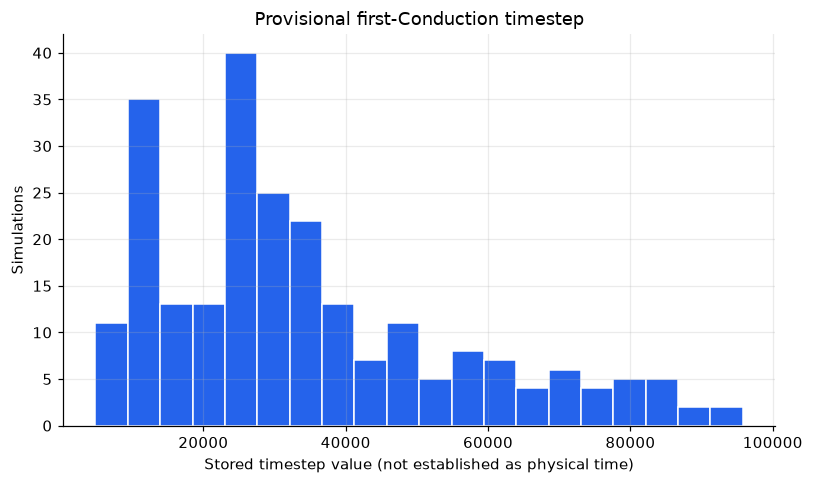

In [19]:
target_rows = simulation_level_audit.loc[simulation_level_audit["reaches_conduction"]].copy()

fig, axis = plt.subplots(figsize=(7.5, 4.5))
axis.hist(target_rows["first_conduction_timestep"], bins=20, color="#2563EB", edgecolor="white")
axis.set_title("Provisional first-Conduction timestep")
axis.set_xlabel("Stored timestep value (not established as physical time)")
axis.set_ylabel("Simulations")
fig.tight_layout()
fig.savefig(OUTPUT_DIRECTORY / "first_conduction_timestep_histogram.png", bbox_inches="tight")
plt.show()


**Interpretation.** First-Conduction timestep is right-skewed and spans roughly 4,840 to 95,798. This broad target range may be learnable, but its physical meaning and sensitivity to schedule differences must be resolved before regression.


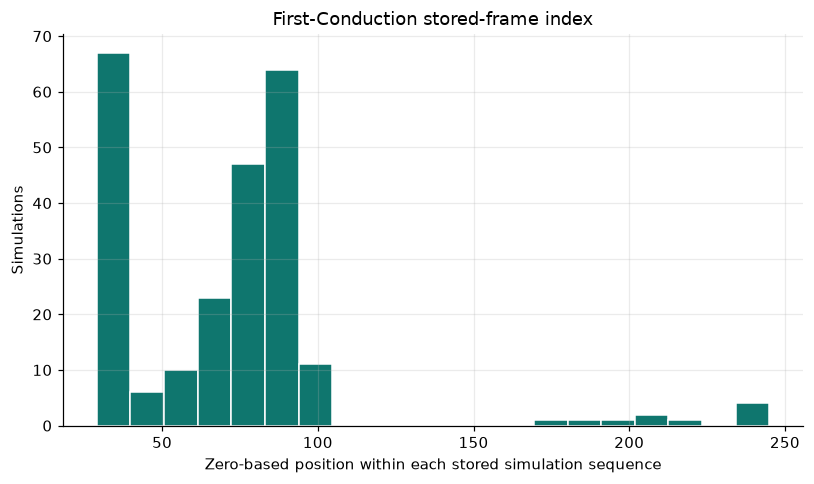

In [20]:
fig, axis = plt.subplots(figsize=(7.5, 4.5))
axis.hist(target_rows["first_conduction_frame_index_0based"], bins=20, color="#0F766E", edgecolor="white")
axis.set_title("First-Conduction stored-frame index")
axis.set_xlabel("Zero-based position within each stored simulation sequence")
axis.set_ylabel("Simulations")
fig.tight_layout()
fig.savefig(OUTPUT_DIRECTORY / "first_conduction_frame_index_histogram.png", bbox_inches="tight")
plt.show()


**Interpretation.** The stored-frame index has a different shape and scale from raw timestep. It measures ordering among retained frames, not simulator time. The distinction will affect both target selection and any later error metric.


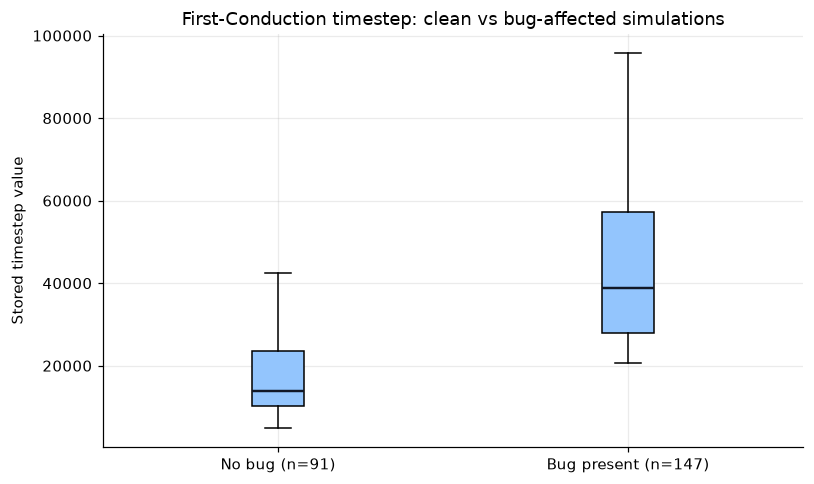

In [21]:
clean_targets = target_rows.loc[~target_rows["screenshot_bug_any"], "first_conduction_timestep"]
bug_targets = target_rows.loc[target_rows["screenshot_bug_any"], "first_conduction_timestep"]
fig, axis = plt.subplots(figsize=(7.5, 4.5))
axis.boxplot(
    [clean_targets, bug_targets],
    tick_labels=[f"No bug (n={len(clean_targets)})", f"Bug present (n={len(bug_targets)})"],
    patch_artist=True,
    boxprops={"facecolor": "#93C5FD"},
    medianprops={"color": "#111827", "linewidth": 1.6},
)
axis.set_title("First-Conduction timestep: clean vs bug-affected simulations")
axis.set_ylabel("Stored timestep value")
fig.tight_layout()
fig.savefig(OUTPUT_DIRECTORY / "clean_vs_bug_affected_first_conduction.png", bbox_inches="tight")
plt.show()


**Interpretation.** Bug-affected simulations occupy a visibly different target range from clean simulations. This comparison does not prove that the bug causes later transition; process inputs and storage schedules may also differ. It does show that filtering policy can materially change the regression sample and target distribution.


## Section 11 — Clean-subset alternatives


In [22]:
candidate_masks = {
    "A — Broad": simulation_level_audit["reaches_conduction"],
    "B — Strict clean": (
        simulation_level_audit["reaches_conduction"]
        & ~simulation_level_audit["screenshot_bug_any"]
    ),
    "C — Pre-transition clean": (
        simulation_level_audit["reaches_conduction"]
        & ~simulation_level_audit["screenshot_bug_before_first_conduction"]
    ),
}

candidate_rows = []
for candidate_name, mask in candidate_masks.items():
    candidate = simulation_level_audit.loc[mask].copy()
    duplicate_4d_combinations = int(
        candidate.groupby(PARAMETERS, dropna=False).size().gt(1).sum()
    )
    row = {
        "candidate": candidate_name,
        "simulations": int(len(candidate)),
        "screenshot_bug_any": int(candidate["screenshot_bug_any"].sum()),
        "screenshot_bug_before_first": int(candidate["screenshot_bug_before_first_conduction"].sum()),
        "duplicated_4d_combinations": duplicate_4d_combinations,
        "target_min": float(candidate["first_conduction_timestep"].min()),
        "target_q25": float(candidate["first_conduction_timestep"].quantile(0.25)),
        "target_median": float(candidate["first_conduction_timestep"].median()),
        "target_q75": float(candidate["first_conduction_timestep"].quantile(0.75)),
        "target_max": float(candidate["first_conduction_timestep"].max()),
    }
    for parameter in PARAMETERS:
        row[f"{parameter}_unique"] = int(candidate[parameter].nunique())
        row[f"{parameter}_min"] = float(candidate[parameter].min())
        row[f"{parameter}_max"] = float(candidate[parameter].max())
    candidate_rows.append(row)

candidate_subset_summary = pd.DataFrame(candidate_rows)
display(candidate_subset_summary)


,candidate,simulations,screenshot_bug_any,screenshot_bug_before_first,duplicated_4d_combinations,target_min,target_q25,target_median,target_q75,target_max,P_unique,P_min,P_max,VX_unique,VX_min,VX_max,LS_unique,LS_min,LS_max,ST_unique,ST_min,ST_max
0,A — Broad,238,147,147,0,4840.0,19420.75,29019.0,44656.75,95798.0,238,52.544586,248.695097,229,0.201002,0.998321,212,0.000045,0.00009,212,300.0,399.457924
1,B — Strict clean,91,0,0,0,4840.0,10285.50,13933.0,23643.50,42436.0,91,52.544586,246.882256,91,0.201002,0.998321,65,0.000045,0.00009,65,300.0,399.457924
2,C — Pre-transition clean,91,0,0,0,4840.0,10285.50,13933.0,23643.50,42436.0,91,52.544586,246.882256,91,0.201002,0.998321,65,0.000045,0.00009,65,300.0,399.457924


**Interpretation.** Candidate A retains 238 target-bearing simulations. Candidates B and C each retain 91 simulations and are identical in this revision because every target-bearing simulation with any Screenshot Bug also has a bug before first Conduction. All candidates retain unique 4D parameter combinations, but the clean candidates substantially reduce input-space coverage and shift the target distribution. No policy is selected here; the trade-off requires review.


## Target ambiguity, censoring and persistent onset audit

In the refinement below, the historical columns `first_conduction_timestep` and `first_conduction_frame_index_0based` are retained for reproducibility and explicitly aliased as `first_observed_conduction_timestep` and `first_observed_conduction_frame_index_0based`. They identify the first stored row labelled `Conduction`; they do **not** establish the true physical transition time. In bug-affected sequences, the first observed Conduction can be upper-bound-like.

For each target-bearing simulation, the conservative **observational ambiguity interval** uses the latest earlier valid non-bug label other than `Conduction` or `Keyhole` as its lower bound, and the first observed Conduction timestep as its upper bound. This is not a probabilistic confidence interval. No interpolation is invented, and no interval midpoint is proposed as a regression target.


In [23]:
REVERSION_LABELS = {"Forming Phase", "Initial Emptiness"}
INVALID_PRECONDUCTION_LOWER_BOUND_LABELS = {"Screenshot Bug", "Conduction", "Keyhole"}

target_refinement_rows = []
for simulation_name, group in raw.groupby(GROUP_KEY, sort=False):
    ordered = group.sort_values("timestep", kind="stable").reset_index(drop=True)
    labels = ordered["label_final"].astype(str).tolist()
    timesteps = ordered["timestep"].astype(int).tolist()

    conduction_positions = [index for index, label in enumerate(labels) if label == "Conduction"]
    first_observed_position = conduction_positions[0] if conduction_positions else None
    preconduction_positions = range(first_observed_position) if first_observed_position is not None else []
    preconduction_bug_positions = [
        position for position in preconduction_positions if labels[position] == "Screenshot Bug"
    ]
    valid_lower_bound_positions = [
        position
        for position in preconduction_positions
        if labels[position] not in INVALID_PRECONDUCTION_LOWER_BOUND_LABELS
    ]
    latest_valid_lower_position = (
        valid_lower_bound_positions[-1] if valid_lower_bound_positions else None
    )

    persistent_position = next(
        (
            position
            for position in conduction_positions
            if not any(label in REVERSION_LABELS for label in labels[position + 1 :])
        ),
        None,
    )

    if first_observed_position is not None and persistent_position is not None:
        intervening_labels = labels[first_observed_position + 1 : persistent_position]
        intervening_reversion_flags = [label in REVERSION_LABELS for label in intervening_labels]
        intervening_reversion_count = sum(
            is_reversion
            and (index == 0 or not intervening_reversion_flags[index - 1])
            for index, is_reversion in enumerate(intervening_reversion_flags)
        )
        intervening_reversion_frame_count = int(sum(intervening_reversion_flags))
    else:
        intervening_reversion_count = pd.NA
        intervening_reversion_frame_count = pd.NA

    valid_non_bug_positions = [
        position for position, label in enumerate(labels) if label != "Screenshot Bug"
    ]
    final_valid_non_bug_position = valid_non_bug_positions[-1] if valid_non_bug_positions else None

    first_observed_timestep = (
        timesteps[first_observed_position] if first_observed_position is not None else pd.NA
    )
    ambiguity_lower_bound = (
        timesteps[latest_valid_lower_position]
        if latest_valid_lower_position is not None
        else pd.NA
    )
    ambiguity_upper_bound = first_observed_timestep
    ambiguity_width = (
        int(ambiguity_upper_bound - ambiguity_lower_bound)
        if first_observed_position is not None and latest_valid_lower_position is not None
        else pd.NA
    )
    persistent_timestep = (
        timesteps[persistent_position] if persistent_position is not None else pd.NA
    )

    target_refinement_rows.append(
        {
            GROUP_KEY: simulation_name,
            "first_observed_conduction_timestep": first_observed_timestep,
            "first_observed_conduction_frame_index_0based": (
                first_observed_position if first_observed_position is not None else pd.NA
            ),
            "screenshot_bug_frames_before_first_observed_conduction": int(
                len(preconduction_bug_positions)
            ),
            "latest_valid_preconduction_timestep": ambiguity_lower_bound,
            "latest_valid_preconduction_label": (
                labels[latest_valid_lower_position]
                if latest_valid_lower_position is not None
                else pd.NA
            ),
            "first_screenshot_bug_timestep_before_first_observed_conduction": (
                timesteps[preconduction_bug_positions[0]]
                if preconduction_bug_positions
                else pd.NA
            ),
            "last_screenshot_bug_timestep_before_first_observed_conduction": (
                timesteps[preconduction_bug_positions[-1]]
                if preconduction_bug_positions
                else pd.NA
            ),
            "observational_ambiguity_interval_lower_bound": ambiguity_lower_bound,
            "observational_ambiguity_interval_upper_bound": ambiguity_upper_bound,
            "observational_ambiguity_interval_width": ambiguity_width,
            "observational_ambiguity_lower_bound_exists": bool(
                latest_valid_lower_position is not None
            ),
            "first_persistent_conduction_timestep": persistent_timestep,
            "first_persistent_conduction_frame_index_0based": (
                persistent_position if persistent_position is not None else pd.NA
            ),
            "persistent_onset_exists": bool(persistent_position is not None),
            "persistent_onset_differs_from_first_observed": (
                bool(persistent_position != first_observed_position)
                if persistent_position is not None and first_observed_position is not None
                else pd.NA
            ),
            "persistent_minus_first_observed_timestep": (
                int(persistent_timestep - first_observed_timestep)
                if persistent_position is not None and first_observed_position is not None
                else pd.NA
            ),
            "intervening_reversion_count": intervening_reversion_count,
            "intervening_reversion_frame_count": intervening_reversion_frame_count,
            "final_observed_timestep": int(timesteps[-1]),
            "final_stored_frame_index_0based": int(len(labels) - 1),
            "final_observed_label": labels[-1],
            "final_valid_non_bug_timestep": (
                timesteps[final_valid_non_bug_position]
                if final_valid_non_bug_position is not None
                else pd.NA
            ),
            "final_valid_label": (
                labels[final_valid_non_bug_position]
                if final_valid_non_bug_position is not None
                else pd.NA
            ),
            "right_censored_no_conduction": bool(first_observed_position is None),
        }
    )

target_refinement_audit = pd.DataFrame(target_refinement_rows)
simulation_level_audit = simulation_level_audit.merge(
    target_refinement_audit, on=GROUP_KEY, how="left", validate="one_to_one"
)

nullable_integer_columns = [
    "first_observed_conduction_timestep",
    "first_observed_conduction_frame_index_0based",
    "screenshot_bug_frames_before_first_observed_conduction",
    "latest_valid_preconduction_timestep",
    "first_screenshot_bug_timestep_before_first_observed_conduction",
    "last_screenshot_bug_timestep_before_first_observed_conduction",
    "observational_ambiguity_interval_lower_bound",
    "observational_ambiguity_interval_upper_bound",
    "observational_ambiguity_interval_width",
    "first_persistent_conduction_timestep",
    "first_persistent_conduction_frame_index_0based",
    "persistent_minus_first_observed_timestep",
    "intervening_reversion_count",
    "intervening_reversion_frame_count",
    "final_observed_timestep",
    "final_stored_frame_index_0based",
    "final_valid_non_bug_timestep",
]
for column in nullable_integer_columns:
    simulation_level_audit[column] = simulation_level_audit[column].astype("Int64")
simulation_level_audit["persistent_onset_differs_from_first_observed"] = (
    simulation_level_audit["persistent_onset_differs_from_first_observed"].astype("boolean")
)

historical_target_matches_alias = (
    simulation_level_audit["first_conduction_timestep"].astype("Int64")
    .equals(simulation_level_audit["first_observed_conduction_timestep"])
)
historical_index_matches_alias = (
    simulation_level_audit["first_conduction_frame_index_0based"].astype("Int64")
    .equals(simulation_level_audit["first_observed_conduction_frame_index_0based"])
)
assert historical_target_matches_alias and historical_index_matches_alias

simulation_level_audit["exact_clean_observed_target"] = (
    simulation_level_audit["reaches_conduction"]
    & ~simulation_level_audit["screenshot_bug_before_first_conduction"]
)
simulation_level_audit["interval_ambiguous_due_to_pretransition_bug"] = (
    simulation_level_audit["reaches_conduction"]
    & simulation_level_audit["screenshot_bug_before_first_conduction"]
)
simulation_level_audit["other_transition_ambiguity"] = (
    simulation_level_audit["reaches_conduction"]
    & (
        simulation_level_audit["conduction_entry_count"].gt(1)
        | simulation_level_audit["return_to_forming_or_initial_after_conduction"]
    )
)

target_primary_order = [
    "right_censored_no_conduction",
    "interval_ambiguous_due_to_pretransition_bug",
    "other_transition_ambiguity",
    "exact_clean_observed_target",
]
simulation_level_audit["target_status_primary"] = np.select(
    [
        simulation_level_audit["right_censored_no_conduction"],
        simulation_level_audit["interval_ambiguous_due_to_pretransition_bug"],
        simulation_level_audit["other_transition_ambiguity"],
        simulation_level_audit["exact_clean_observed_target"],
    ],
    target_primary_order,
    default="other_transition_ambiguity",
)

target_status_primary_summary = (
    simulation_level_audit["target_status_primary"]
    .value_counts()
    .reindex(target_primary_order, fill_value=0)
    .rename_axis("target_status_primary")
    .reset_index(name="simulations")
)
display(target_status_primary_summary)


,target_status_primary,simulations
0,right_censored_no_conduction,3
1,interval_ambiguous_due_to_pretransition_bug,147
2,other_transition_ambiguity,22
3,exact_clean_observed_target,69


**Classification rules.** Four Boolean flags are retained because different scientific concerns can overlap. `exact_clean_observed_target` means that Conduction is observed and no Screenshot Bug precedes it; it does not erase a separate transition-instability flag. `interval_ambiguous_due_to_pretransition_bug` marks target-bearing simulations with a pre-transition Screenshot Bug. `right_censored_no_conduction` marks simulations without an observed Conduction label. `other_transition_ambiguity` marks multiple entries into Conduction or a later return to Forming Phase / Initial Emptiness.

For one mutually exclusive summary, priority is right-censored, then pre-transition-bug interval ambiguity, then other transition ambiguity, then exact/clean. Thus 91 simulations carry the exact/clean flag, while 69 have it as their primary category; the other 22 clean simulations also carry an independent transition-ambiguity flag. This preserves both the requested clean count and the overlapping scientific warning.


,metric,scope,value,unit_or_note
0,exact_clean_observed_target_flag,target-bearing simulations,91.000000,simulations
1,interval_ambiguous_due_to_pretransition_bug,target-bearing simulations,147.000000,simulations
2,unavailable_valid_lower_bound,all target-bearing simulations,0.000000,simulations
3,unavailable_valid_lower_bound,interval-ambiguous simulations,0.000000,simulations
4,interval_width_count,interval-ambiguous simulations with valid lower bound,147.000000,simulations
5,interval_width_mean,interval-ambiguous simulations with valid lower bound,513.231293,stored timestep units
6,interval_width_std,interval-ambiguous simulations with valid lower bound,249.023822,stored timestep units
7,interval_width_min,interval-ambiguous simulations with valid lower bound,267.000000,stored timestep units
8,interval_width_q25,interval-ambiguous simulations with valid lower bound,314.500000,stored timestep units
9,interval_width_median,interval-ambiguous simulations with valid lower bound,418.000000,stored timestep units


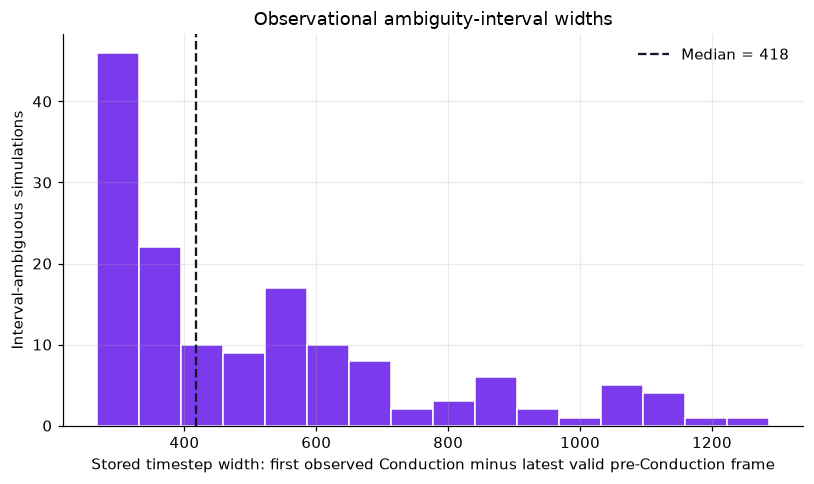

In [24]:
interval_ambiguous_rows = simulation_level_audit.loc[
    simulation_level_audit["interval_ambiguous_due_to_pretransition_bug"]
].copy()
interval_width_rows = interval_ambiguous_rows.loc[
    interval_ambiguous_rows["observational_ambiguity_lower_bound_exists"]
].copy()
interval_widths = interval_width_rows["observational_ambiguity_interval_width"].astype(float)
width_description = interval_widths.describe(percentiles=[0.25, 0.5, 0.75])
width_first_observed_pearson = interval_widths.corr(
    interval_width_rows["first_observed_conduction_timestep"].astype(float), method="pearson"
)
width_first_observed_spearman = interval_widths.corr(
    interval_width_rows["first_observed_conduction_timestep"].astype(float), method="spearman"
)

target_ambiguity_summary_rows = [
    ("exact_clean_observed_target_flag", "target-bearing simulations", int(simulation_level_audit["exact_clean_observed_target"].sum()), "simulations"),
    ("interval_ambiguous_due_to_pretransition_bug", "target-bearing simulations", int(simulation_level_audit["interval_ambiguous_due_to_pretransition_bug"].sum()), "simulations"),
    ("unavailable_valid_lower_bound", "all target-bearing simulations", int((simulation_level_audit["reaches_conduction"] & ~simulation_level_audit["observational_ambiguity_lower_bound_exists"]).sum()), "simulations"),
    ("unavailable_valid_lower_bound", "interval-ambiguous simulations", int((simulation_level_audit["interval_ambiguous_due_to_pretransition_bug"] & ~simulation_level_audit["observational_ambiguity_lower_bound_exists"]).sum()), "simulations"),
    ("interval_width_count", "interval-ambiguous simulations with valid lower bound", int(width_description["count"]), "simulations"),
    ("interval_width_mean", "interval-ambiguous simulations with valid lower bound", float(width_description["mean"]), "stored timestep units"),
    ("interval_width_std", "interval-ambiguous simulations with valid lower bound", float(width_description["std"]), "stored timestep units"),
    ("interval_width_min", "interval-ambiguous simulations with valid lower bound", float(width_description["min"]), "stored timestep units"),
    ("interval_width_q25", "interval-ambiguous simulations with valid lower bound", float(width_description["25%"]), "stored timestep units"),
    ("interval_width_median", "interval-ambiguous simulations with valid lower bound", float(width_description["50%"]), "stored timestep units"),
    ("interval_width_q75", "interval-ambiguous simulations with valid lower bound", float(width_description["75%"]), "stored timestep units"),
    ("interval_width_max", "interval-ambiguous simulations with valid lower bound", float(width_description["max"]), "stored timestep units"),
    ("width_vs_first_observed_pearson", "interval-ambiguous simulations with valid lower bound", float(width_first_observed_pearson), "correlation"),
    ("width_vs_first_observed_spearman", "interval-ambiguous simulations with valid lower bound", float(width_first_observed_spearman), "rank correlation"),
]
for status_row in target_status_primary_summary.itertuples(index=False):
    target_ambiguity_summary_rows.append(
        (f"primary_category::{status_row.target_status_primary}", "all simulations", int(status_row.simulations), "simulations")
    )
target_ambiguity_summary = pd.DataFrame(
    target_ambiguity_summary_rows,
    columns=["metric", "scope", "value", "unit_or_note"],
)
display(target_ambiguity_summary)

fig, axis = plt.subplots(figsize=(7.5, 4.5))
axis.hist(interval_widths, bins=16, color="#7C3AED", edgecolor="white")
axis.axvline(
    interval_widths.median(),
    color="#111827",
    linestyle="--",
    linewidth=1.5,
    label=f"Median = {interval_widths.median():.0f}",
)
axis.set_title("Observational ambiguity-interval widths")
axis.set_xlabel("Stored timestep width: first observed Conduction minus latest valid pre-Conduction frame")
axis.set_ylabel("Interval-ambiguous simulations")
axis.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIRECTORY / "ambiguity_interval_widths.png", bbox_inches="tight")
plt.show()


**Ambiguity findings.** There are 91 exact/clean observed targets and 147 interval-ambiguous targets. Every target-bearing simulation has a valid conservative lower bound in this dataset revision. Among the 147 bug-affected intervals, widths range from 267 to 1,287 stored timestep units (median 418; mean 513.23; interquartile range 314.5 to 630). Width is positively associated with the first observed target (Pearson 0.795; Spearman 0.783), which is descriptive of the storage schedule and bug interval, not evidence for a physical causal mechanism.


In [25]:
right_censored_simulations = simulation_level_audit.loc[
    simulation_level_audit["right_censored_no_conduction"],
    [
        GROUP_KEY,
        "final_observed_timestep",
        "final_stored_frame_index_0based",
        "final_observed_label",
        "final_valid_non_bug_timestep",
        "final_valid_label",
        "screenshot_bug_any",
        "keyhole_any",
        *PARAMETERS,
        "right_censored_no_conduction",
    ],
].reset_index(drop=True)
assert len(right_censored_simulations) == 3
display(right_censored_simulations)


,name,final_observed_timestep,final_stored_frame_index_0based,final_observed_label,final_valid_non_bug_timestep,final_valid_label,screenshot_bug_any,keyhole_any,P,VX,LS,ST,right_censored_no_conduction
0,P-208p39901443_VX-0p201684842681_LS-6p50424237325e-05_ST-372p154003234_M-TI64_XI-0p0002_XF-0p001...,68795,40,Forming Phase,68795,Forming Phase,True,False,208.399014,0.201685,0.000065,372.154003,True
1,P-211p816522505_VX-0p520710876808_LS-4p80782604054e-05_ST-318p660442183_M-TI64_XI-0p0002_XF-0p00...,115599,227,Keyhole,115599,Keyhole,True,True,211.816523,0.520711,0.000048,318.660442,True
2,P-98p5137427197_VX-0p87794698955_LS-7p93698578539e-05_ST-325p506902574_M-TI64_XI-0p0002_XF-0p001...,68795,170,Forming Phase,68795,Forming Phase,True,False,98.513743,0.877947,0.000079,325.506903,True


**Right-censoring interpretation.** These three simulations are not ordinary missing-at-random target rows: their Conduction transition, if it occurs, is known only to be later than the final observation. `final_valid_label` excludes `Screenshot Bug` but retains `Keyhole` as an observed state. A standard `GaussianProcessRegressor` cannot directly consume right-censored targets without additional likelihood or modelling assumptions. Excluding the three rows may be acceptable for the initial supervisor-requested warm-up, but the exclusion must be reported. No survival analysis or censored-GP likelihood is implemented here.


In [26]:
persistent_onset_comparison = simulation_level_audit.loc[
    simulation_level_audit["reaches_conduction"],
    [
        GROUP_KEY,
        "first_observed_conduction_timestep",
        "first_observed_conduction_frame_index_0based",
        "first_persistent_conduction_timestep",
        "first_persistent_conduction_frame_index_0based",
        "persistent_onset_exists",
        "persistent_onset_differs_from_first_observed",
        "persistent_minus_first_observed_timestep",
        "intervening_reversion_count",
        "intervening_reversion_frame_count",
        "conduction_entry_count",
        "return_to_forming_or_initial_after_conduction",
        "screenshot_bug_before_first_conduction",
        "keyhole_any",
        "transition_pattern",
    ],
].reset_index(drop=True)

persistent_summary = pd.DataFrame(
    {
        "metric": [
            "target-bearing simulations",
            "persistent onset exists",
            "persistent onset unavailable",
            "persistent onset differs from first observed",
        ],
        "simulations": [
            int(simulation_level_audit["reaches_conduction"].sum()),
            int(simulation_level_audit["persistent_onset_exists"].sum()),
            int((simulation_level_audit["reaches_conduction"] & ~simulation_level_audit["persistent_onset_exists"]).sum()),
            int(simulation_level_audit["persistent_onset_differs_from_first_observed"].fillna(False).sum()),
        ],
    }
)
display(persistent_summary)

persistent_examples = pd.concat(
    [
        persistent_onset_comparison.loc[
            persistent_onset_comparison["persistent_onset_differs_from_first_observed"].fillna(False)
        ].assign(example_type="persistent onset differs"),
        persistent_onset_comparison.loc[
            ~persistent_onset_comparison["persistent_onset_exists"]
        ].head(3).assign(example_type="no persistent onset under diagnostic"),
        persistent_onset_comparison.loc[
            persistent_onset_comparison["persistent_onset_exists"]
            & ~persistent_onset_comparison["persistent_onset_differs_from_first_observed"].fillna(False)
        ].head(2).assign(example_type="first observed already persistent"),
    ],
    ignore_index=True,
)
display(
    persistent_examples[
        [
            "example_type",
            GROUP_KEY,
            "first_observed_conduction_timestep",
            "first_persistent_conduction_timestep",
            "persistent_minus_first_observed_timestep",
            "intervening_reversion_count",
            "transition_pattern",
        ]
    ]
)


,metric,simulations
0,target-bearing simulations,238
1,persistent onset exists,220
2,persistent onset unavailable,18
3,persistent onset differs from first observed,2


,example_type,name,first_observed_conduction_timestep,first_persistent_conduction_timestep,persistent_minus_first_observed_timestep,intervening_reversion_count,transition_pattern
0,persistent onset differs,P-52p5445860993_VX-0p633129978235_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_TE-0p0...,13322,31513,18191,1,Initial Emptiness → Forming Phase → Conduction → Forming Phase → Conduction
1,persistent onset differs,P-77p6071708937_VX-0p433253784538_LS-7p48831675656e-05_ST-344p207921637_M-TI64_XI-0p0002_XF-0p00...,44723,50241,5518,1,Screenshot Bug → Forming Phase → Conduction → Forming Phase → Conduction
2,no persistent onset under diagnostic,P-102p449509144_VX-0p918837420936_LS-5p51471704636e-05_ST-339p471112188_M-TI64_XI-0p0002_XF-0p00...,10686,<NA>,<NA>,<NA>,Initial Emptiness → Conduction → Initial Emptiness
3,no persistent onset under diagnostic,P-118p139890353_VX-0p847347819728_LS-5p08934239386e-05_ST-372p913421628_M-TI64_XI-0p0002_XF-0p00...,11588,<NA>,<NA>,<NA>,Initial Emptiness → Conduction → Initial Emptiness
4,no persistent onset under diagnostic,P-131p049819122_VX-0p780196421599_LS-5p30845028915e-05_ST-389p742843455_M-TI64_XI-0p0002_XF-0p00...,12245,<NA>,<NA>,<NA>,Initial Emptiness → Conduction → Initial Emptiness
5,first observed already persistent,P-101p127472137_VX-0p52394730996_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_TE-0p00...,11779,11779,0,0,Initial Emptiness → Forming Phase → Conduction
6,first observed already persistent,P-104p101541641_VX-0p916529700054_LS-8p82882842693e-05_ST-394p968412652_M-TI64_XI-0p0002_XF-0p00...,71553,71553,0,0,Screenshot Bug → Initial Emptiness → Forming Phase → Conduction → Screenshot Bug


**Persistent onset diagnostic.** `first_persistent_conduction_timestep` is the earliest observed Conduction row after which no later frame labelled Forming Phase or Initial Emptiness appears. Later Screenshot Bug frames and later Keyhole frames do not invalidate persistence; however, a direct move to Keyhole is never used to infer an unobserved Conduction event. An intervening reversion is counted as an entry into a contiguous run of Forming Phase / Initial Emptiness between first observed and persistent Conduction.

A persistent onset exists for 220 of 238 target-bearing simulations. It is unavailable for 18 simulations whose last observed Conduction is followed by a later valid reversion and no subsequent Conduction. The diagnostic shifts the onset in 2 simulations; their timestep differences are 18,191 and 5,518, each with one intervening reversion. This is a provisional diagnostic definition that must be confirmed with Ioan before it becomes a regression target.


In [27]:
policy_specs = [
    {
        "policy_id": 1,
        "policy": "Policy 1 — Clean first observed onset",
        "mask": simulation_level_audit["exact_clean_observed_target"],
        "target_column": "first_observed_conduction_timestep",
        "interpretation": "Exact observed target under current labels; reduced input-space coverage",
    },
    {
        "policy_id": 2,
        "policy": "Policy 2 — Broad first observed onset",
        "mask": simulation_level_audit["reaches_conduction"],
        "target_column": "first_observed_conduction_timestep",
        "interpretation": "Bug-affected values retained as first observed / possible upper bounds",
    },
    {
        "policy_id": 3,
        "policy": "Policy 3 — Clean persistent onset",
        "mask": (
            simulation_level_audit["exact_clean_observed_target"]
            & simulation_level_audit["persistent_onset_exists"]
        ),
        "target_column": "first_persistent_conduction_timestep",
        "interpretation": "More conservative diagnostic; excludes clean runs without a persistent onset",
    },
    {
        "policy_id": 4,
        "policy": "Policy 4 — Broad persistent onset diagnostic",
        "mask": simulation_level_audit["persistent_onset_exists"],
        "target_column": "first_persistent_conduction_timestep",
        "interpretation": "All persistent onsets retained; Screenshot Bug ambiguity remains",
    },
]

target_policy_rows = []
for specification in policy_specs:
    candidate = simulation_level_audit.loc[specification["mask"]].copy()
    target = candidate[specification["target_column"]].astype(float)
    row = {
        "policy_id": specification["policy_id"],
        "policy": specification["policy"],
        "target_column": specification["target_column"],
        "interpretation": specification["interpretation"],
        "sample_size": int(len(candidate)),
        "target_min": float(target.min()),
        "target_q25": float(target.quantile(0.25)),
        "target_median": float(target.median()),
        "target_q75": float(target.quantile(0.75)),
        "target_max": float(target.max()),
        "suspicious_transition_simulations": int(candidate["suspicious_transition"].sum()),
        "screenshot_bug_affected_simulations": int(candidate["screenshot_bug_any"].sum()),
        "pretransition_bug_affected_simulations": int(
            candidate["screenshot_bug_before_first_conduction"].sum()
        ),
        "persistent_comparison_available": int(candidate["persistent_onset_exists"].sum()),
        "persistent_differs_from_first_observed": int(
            candidate["persistent_onset_differs_from_first_observed"].fillna(False).sum()
        ),
    }
    for parameter in PARAMETERS:
        row[f"{parameter}_unique"] = int(candidate[parameter].nunique())
        row[f"{parameter}_min"] = float(candidate[parameter].min())
        row[f"{parameter}_max"] = float(candidate[parameter].max())
    target_policy_rows.append(row)

target_policy_comparison = pd.DataFrame(target_policy_rows)
display(target_policy_comparison)


,policy_id,policy,target_column,interpretation,sample_size,target_min,target_q25,target_median,target_q75,target_max,suspicious_transition_simulations,screenshot_bug_affected_simulations,pretransition_bug_affected_simulations,persistent_comparison_available,persistent_differs_from_first_observed,P_unique,P_min,P_max,VX_unique,VX_min,VX_max,LS_unique,LS_min,LS_max,ST_unique,ST_min,ST_max
0,1,Policy 1 — Clean first observed onset,first_observed_conduction_timestep,Exact observed target under current labels; reduced input-space coverage,91,4840.0,10285.50,13933.0,23643.50,42436.0,22,0,0,73,1,91,52.544586,246.882256,91,0.201002,0.998321,65,0.000045,0.00009,65,300.0,399.457924
1,2,Policy 2 — Broad first observed onset,first_observed_conduction_timestep,Bug-affected values retained as first observed / possible upper bounds,238,4840.0,19420.75,29019.0,44656.75,95798.0,169,147,147,220,2,238,52.544586,248.695097,229,0.201002,0.998321,212,0.000045,0.00009,212,300.0,399.457924
2,3,Policy 3 — Clean persistent onset,first_persistent_conduction_timestep,More conservative diagnostic; excludes clean runs without a persistent onset,73,4840.0,11568.00,16402.0,26532.00,42436.0,4,0,0,73,1,73,52.544586,246.882256,73,0.201002,0.986228,47,0.000045,0.00009,47,300.0,398.693211
3,4,Policy 4 — Broad persistent onset diagnostic,first_persistent_conduction_timestep,All persistent onsets retained; Screenshot Bug ambiguity remains,220,4840.0,23396.00,30279.5,48447.75,95798.0,151,147,147,220,2,220,52.544586,248.695097,211,0.201002,0.995510,194,0.000045,0.00009,194,300.0,399.182507


**Policy comparison, without selection.** Policy 1 contains 91 first-observed targets (median 13,933; range 4,840 to 42,436). Policy 2 contains 238 (median 29,019; range 4,840 to 95,798). Policy 3 contains 73 clean persistent targets (median 16,402; range 4,840 to 42,436). Policy 4 contains 220 broad persistent targets (median 30,279.5; range 4,840 to 95,798). The table makes input coverage, suspicious transitions, Screenshot Bug exposure, and first-versus-persistent differences explicit. No final target policy is chosen in this audit.


## Section 12 — Save small audit artifacts


In [28]:
ioan_requirement_status = pd.DataFrame(
    [
        ("Real dataset accessed", "completed", "Sections 2–3", "Pinned CSV downloaded/cached and audited"),
        ("Four process inputs identified", "completed", "Sections 3, 6–7", "P, VX, LS, ST present and constant within name groups"),
        ("Simulation-level grouping identified", "completed", "Section 6", "name justified provisionally; hash rejected"),
        ("First-observed Conduction target investigated", "partially completed", "Sections 9–11 + refinement", "Extractable for 238/241; ambiguity and policy unresolved"),
        ("Target ambiguity and right-censoring audited", "completed", "Target ambiguity refinement", "91 clean, 147 interval-ambiguous, 3 right-censored"),
        ("Persistent onset diagnostic", "completed", "Target ambiguity refinement", "Computed as a diagnostic only; Ioan confirmation required"),
        ("Physical-time interpretation", "blocked by data ambiguity", "Sections 8, 13", "DT/TE semantics are not documented here"),
        ("GP regression", "not started", "Sections 1, 13", "Intentionally outside Phase 1"),
        ("RBF kernel comparison", "not started", "Sections 1, 13", "Intentionally outside Phase 1"),
        ("Matérn 3/2 comparison", "not started", "Sections 1, 13", "Intentionally outside Phase 1"),
        ("Matérn 5/2 comparison", "not started", "Sections 1, 13", "Intentionally outside Phase 1"),
        ("Hyperparameter optimization", "not started", "Sections 1, 13", "Intentionally outside Phase 1"),
        ("Optimizer comparison", "not started", "Sections 1, 13", "Intentionally outside Phase 1"),
        ("Leave-one-out evaluation", "not started", "Sections 1, 13", "Intentionally outside Phase 1"),
    ],
    columns=["requirement", "status", "notebook_location", "evidence_or_reason"],
)

raw_schema_summary.to_csv(OUTPUT_DIRECTORY / "raw_schema_summary.csv", index=False)
label_counts.to_csv(OUTPUT_DIRECTORY / "label_counts.csv", index=False)
grouping_audit.to_csv(OUTPUT_DIRECTORY / "simulation_grouping_audit.csv", index=False)
simulation_level_audit.to_csv(OUTPUT_DIRECTORY / "simulation_level_audit.csv", index=False)
candidate_subset_summary.to_csv(OUTPUT_DIRECTORY / "candidate_subset_summary.csv", index=False)
transition_pattern_summary.to_csv(OUTPUT_DIRECTORY / "transition_pattern_summary.csv", index=False)
target_ambiguity_summary.to_csv(OUTPUT_DIRECTORY / "target_ambiguity_summary.csv", index=False)
right_censored_simulations.to_csv(OUTPUT_DIRECTORY / "right_censored_simulations.csv", index=False)
persistent_onset_comparison.to_csv(OUTPUT_DIRECTORY / "persistent_onset_comparison.csv", index=False)
target_policy_comparison.to_csv(OUTPUT_DIRECTORY / "target_policy_comparison.csv", index=False)

data_audit_summary = {
    "source": {
        "repository_id": HF_REPO_ID,
        "filename": HF_FILENAME,
        "revision": HF_REVISION,
        "local_size_bytes": int(DATA_PATH.stat().st_size),
        "sha256": CSV_SHA256,
        "audit_date": date.today().isoformat(),
    },
    "raw_shape": {"rows": int(raw.shape[0]), "columns": int(raw.shape[1])},
    "columns": raw.columns.tolist(),
    "provisional_grouping_key": GROUP_KEY,
    "simulation_count": int(len(simulation_level_audit)),
    "reaching_conduction": int(simulation_level_audit["reaches_conduction"].sum()),
    "never_reaching_conduction": int((~simulation_level_audit["reaches_conduction"]).sum()),
    "screenshot_bug_any": int(simulation_level_audit["screenshot_bug_any"].sum()),
    "screenshot_bug_before_first_conduction": int(
        simulation_level_audit["screenshot_bug_before_first_conduction"].sum()
    ),
    "candidate_sizes": {
        row["candidate"]: int(row["simulations"])
        for row in candidate_rows
    },
    "target_ambiguity": {
        "historical_name": "first_conduction_timestep",
        "preferred_name": "first_observed_conduction_timestep",
        "interpretation": "first stored row labelled Conduction; not proven physical transition time",
        "interval_type": "observational ambiguity interval; not a probabilistic confidence interval",
        "exact_clean_observed_target_flag": int(
            simulation_level_audit["exact_clean_observed_target"].sum()
        ),
        "interval_ambiguous_due_to_pretransition_bug": int(
            simulation_level_audit["interval_ambiguous_due_to_pretransition_bug"].sum()
        ),
        "unavailable_valid_lower_bound_all_target_bearing": int(
            (
                simulation_level_audit["reaches_conduction"]
                & ~simulation_level_audit["observational_ambiguity_lower_bound_exists"]
            ).sum()
        ),
        "interval_width_statistics": {
            "count": int(width_description["count"]),
            "mean": float(width_description["mean"]),
            "std": float(width_description["std"]),
            "min": float(width_description["min"]),
            "q25": float(width_description["25%"]),
            "median": float(width_description["50%"]),
            "q75": float(width_description["75%"]),
            "max": float(width_description["max"]),
        },
        "width_vs_first_observed_target": {
            "pearson": float(width_first_observed_pearson),
            "spearman": float(width_first_observed_spearman),
            "interpretation": "descriptive association only",
        },
        "primary_category_priority": target_primary_order,
        "primary_category_counts": {
            str(row.target_status_primary): int(row.simulations)
            for row in target_status_primary_summary.itertuples(index=False)
        },
        "midpoint_used_as_target": False,
    },
    "right_censoring": {
        "count": int(len(right_censored_simulations)),
        "interpretation": "transition, if any, occurs later than the final observation",
        "standard_gpr_direct_support": False,
        "survival_or_censored_gp_implemented": False,
        "simulations": json.loads(
            right_censored_simulations.to_json(orient="records")
        ),
    },
    "persistent_onset_diagnostic": {
        "definition": "earliest Conduction after which no later Forming Phase or Initial Emptiness appears",
        "later_screenshot_bug_invalidates": False,
        "later_keyhole_invalidates": False,
        "direct_keyhole_implies_conduction": False,
        "target_bearing_simulations": int(simulation_level_audit["reaches_conduction"].sum()),
        "persistent_onset_exists": int(simulation_level_audit["persistent_onset_exists"].sum()),
        "persistent_onset_unavailable": int(
            (
                simulation_level_audit["reaches_conduction"]
                & ~simulation_level_audit["persistent_onset_exists"]
            ).sum()
        ),
        "differs_from_first_observed": int(
            simulation_level_audit["persistent_onset_differs_from_first_observed"]
            .fillna(False)
            .sum()
        ),
        "requires_ioan_confirmation": True,
    },
    "target_policy_comparison": json.loads(
        target_policy_comparison.to_json(orient="records")
    ),
    "timestep_findings": {
        "unsorted_schedules": int((~timestep_audit["timesteps_sorted_in_raw_order"]).sum()),
        "duplicate_timestep_schedules": int(timestep_audit["duplicate_timestep_rows"].gt(0).sum()),
        "exactly_constant_integer_gap_schedules": int(timestep_audit["exactly_constant_integer_gap"].sum()),
        "unique_complete_schedules": int(raw.groupby(GROUP_KEY)["timestep"].apply(tuple).nunique()),
        "nonzero_start_schedules": int(timestep_audit["minimum_timestep"].gt(0).sum()),
        "physical_time_interpretation": "unresolved",
    },
    "important_quality_flags": [
        "hash merges distinct simulation names and is not a valid grouping key",
        "bug_free is always 1 despite Screenshot Bug labels",
        "label_1, label_2, and label_final are identical on every row",
        "some process values fall below current dataset-card lower bounds",
        "timestep schedules and integer gaps vary across simulations",
        "bug-affected first-observed targets have observational ambiguity intervals",
        "three never-Conduction simulations are right-censored",
        "persistent onset is a diagnostic definition requiring supervisor confirmation",
    ],
    "ioan_requirement_status": ioan_requirement_status.to_dict(orient="records"),
    "phase_scope": "data audit only; no Gaussian Process was fitted",
}
with (OUTPUT_DIRECTORY / "data_audit_summary.json").open("w", encoding="utf-8") as handle:
    json.dump(data_audit_summary, handle, indent=2, ensure_ascii=False)

artifact_manifest = pd.DataFrame(
    [
        {"artifact": path.name, "size_bytes": path.stat().st_size}
        for path in sorted(OUTPUT_DIRECTORY.iterdir())
        if path.is_file()
    ]
)
display(artifact_manifest)
print("Raw CSV copied into outputs:", (OUTPUT_DIRECTORY / HF_FILENAME).exists())


,artifact,size_bytes
0,ambiguity_interval_widths.png,43036
1,candidate_subset_summary.csv,812
2,clean_vs_bug_affected_first_conduction.png,30440
3,data_audit_summary.json,13236
4,first_conduction_frame_index_histogram.png,33218
5,first_conduction_timestep_histogram.png,32150
6,label_counts.csv,935
7,label_final_counts.png,39687
8,persistent_onset_comparison.csv,62026
9,process_parameter_distributions.png,94509


Raw CSV copied into outputs: False


**Interpretation.** The saved artifacts are small simulation-level summaries, schema/label/grouping tables, transition-pattern counts, target-ambiguity and policy tables, right-censoring records, persistent-onset comparisons, JSON provenance, and selected figures. The 17.4 MB raw CSV is not copied into `outputs/`. Rerunning overwrites the same named artifacts, so it does not create duplicate versions.


## Section 13 — Conclusions and open decisions

1. **What one simulation appears to be:** one unique `name`, containing a time-ordered sequence of stored frames.
2. **Provisional grouping key:** `name`, because it yields 241 groups with constant `P`, `VX`, `LS`, and `ST`. `hash` is unsafe because it merges different names and inputs.
3. **Input constancy:** all four process parameters are constant within every `name` group.
4. **First observed Conduction:** `first_conduction_timestep` should currently be interpreted as the first stored row labelled Conduction, not as a proven true physical transition time. The explicit alias is `first_observed_conduction_timestep`.
5. **Observational ambiguity interval:** 91 target-bearing simulations are exact/clean under the current labels; 147 have a pre-transition Screenshot Bug. Their first observed Conduction values may be interval-censored / upper-bound-like targets. No interpolation, midpoint target, or formal censoring likelihood is fitted.
6. **Right-censored simulations:** the 3 simulations that never show Conduction are right-censored at their final observations, not ordinary missing-at-random targets.
7. **Persistent onset diagnostic:** literal first onset and persistent onset differ in 2 simulations; 18 additional target-bearing simulations have no persistent onset under the provisional definition. This diagnostic must be confirmed with Ioan.
8. **Target policy:** standard GP regression requires a provisional policy decision before fitting. The four documented policies contain 91, 238, 73, and 220 simulations respectively; none is selected here.
9. **Screenshot Bug:** present in 150 simulations and before first observed Conduction in 147. The `bug_free` field is nevertheless always 1, so the flag cannot currently replace label-sequence inspection.
10. **Timestep meaning:** ordered simulator values, not demonstrated physical time. Each simulation has a distinct schedule and variable integer gaps; `DT` and `TE` are encoded in names but lack a documented conversion here.
11. **Decisions needed before GP fitting:** confirm grouping semantics; explain `hash`, `bug_free`, `DT`, and `TE`; choose among the documented target policies; decide how right-censored cases should be handled; confirm whether timestep or stored-frame index is the intended response.
12. **Recommended next phase:** review these audit findings with Ioan, resolve target/filtering semantics, then specify—but do not yet assume—the regression design and evaluation protocol.

> **Warning:** The file supports extraction of a provisional first observed Conduction event, but it does not yet support an unambiguous physical-time regression target. Fitting a GP before resolving observational ambiguity, right-censoring, persistent-onset semantics, and timestep meaning could produce a precise model of the wrong quantity.


## Ioan Requirement Status — End of Week 5 Phase 1


In [29]:
display(ioan_requirement_status)


,requirement,status,notebook_location,evidence_or_reason
0,Real dataset accessed,completed,Sections 2–3,Pinned CSV downloaded/cached and audited
1,Four process inputs identified,completed,"Sections 3, 6–7","P, VX, LS, ST present and constant within name groups"
2,Simulation-level grouping identified,completed,Section 6,name justified provisionally; hash rejected
3,First-observed Conduction target investigated,partially completed,Sections 9–11 + refinement,Extractable for 238/241; ambiguity and policy unresolved
4,Target ambiguity and right-censoring audited,completed,Target ambiguity refinement,"91 clean, 147 interval-ambiguous, 3 right-censored"
5,Persistent onset diagnostic,completed,Target ambiguity refinement,Computed as a diagnostic only; Ioan confirmation required
6,Physical-time interpretation,blocked by data ambiguity,"Sections 8, 13",DT/TE semantics are not documented here
7,GP regression,not started,"Sections 1, 13",Intentionally outside Phase 1
8,RBF kernel comparison,not started,"Sections 1, 13",Intentionally outside Phase 1
9,Matérn 3/2 comparison,not started,"Sections 1, 13",Intentionally outside Phase 1


**Interpretation.** Data access, input identification, grouping, and target auditing are complete or partially complete in the named sections. GP regression, RBF/Matérn comparisons, hyperparameter/optimizer comparisons, and leave-one-out evaluation are intentionally **not started**. The notebook stops here for review before Phase 2.
